# 05 — Sensitivity to kNN parameter k

**Purpose:** Test sensitivity to k (number of neighbors in the kNN graph). Vary k ∈ {10, 20, 30, 50}, compute spatial metrics, plot stabilization curves.

## Imports and path setup

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# kNN with small k can yield disconnected graph components; libpysal warns. Results are still valid.
warnings.filterwarnings("ignore", message=".*not fully connected.*", category=UserWarning)

from analysis.experiment_runner import _get_run_dirs
from analysis.preprocessing import get_transformed_test_features
from analysis.run_analysis import load_meta, run_multiplicity, run_spatial

RESULTS_DIR = ROOT / "results"

## Loop over k and store results

In [2]:
K = 25
K_NN_LIST = [10, 20, 30, 50]

# Only datasets supported by load_dataset (excludes e.g. synthetic)
SUPPORTED_DATASETS = ("compas", "german", "breast_cancer")
dataset_dirs = [p for p in RESULTS_DIR.iterdir() if p.is_dir() and p.name in SUPPORTED_DATASETS and _get_run_dirs(p)]

def run_one_knn(run_dir, X_test, k_nn):
    n_cand = len(load_meta(run_dir))
    K_actual = min(K, n_cand)
    mult = run_multiplicity(run_dir, K=K_actual)
    spatial = run_spatial(run_dir, X_test, K=K_actual, k=k_nn)
    return {"mean_variance": mult["mean_variance"], "moran_i": spatial["moran_i"], "n_hh": int(np.sum(spatial["HH_mask"]))}

results_knn = []
for dataset_dir in dataset_dirs:
    dataset_name = dataset_dir.name
    run_dirs = _get_run_dirs(dataset_dir)
    for k_nn in K_NN_LIST:
        for run_dir in run_dirs:
            X_test = get_transformed_test_features(run_dir, dataset_name)
            res = run_one_knn(run_dir, X_test, k_nn)
            results_knn.append({"dataset": dataset_name, "k_nn": k_nn, **res})

df_knn = pd.DataFrame(results_knn)
print(df_knn.groupby(["dataset", "k_nn"]).agg({"mean_variance": ["mean", "std"], "moran_i": ["mean", "std"], "n_hh": "mean"}).round(4))

                   mean_variance         moran_i           n_hh
                            mean     std    mean     std   mean
dataset       k_nn                                             
breast_cancer 10          0.0032  0.0026  0.0758  0.0489    1.1
              20          0.0032  0.0026  0.0538  0.0313    1.7
              30          0.0032  0.0026  0.0315  0.0207    1.6
              50          0.0032  0.0026  0.0048  0.0084    1.7
compas        10          0.0013  0.0003  0.2943  0.1146   45.7
              20          0.0013  0.0003  0.2304  0.0837   71.3
              30          0.0013  0.0003  0.1993  0.0772   86.7
              50          0.0013  0.0003  0.1627  0.0646  112.8
german        10          0.0050  0.0021  0.1576  0.0653    1.5
              20          0.0050  0.0021  0.1280  0.0485    3.1
              30          0.0050  0.0021  0.1042  0.0397    2.7
              50          0.0050  0.0021  0.0744  0.0300    2.0


## Plot elbow curves

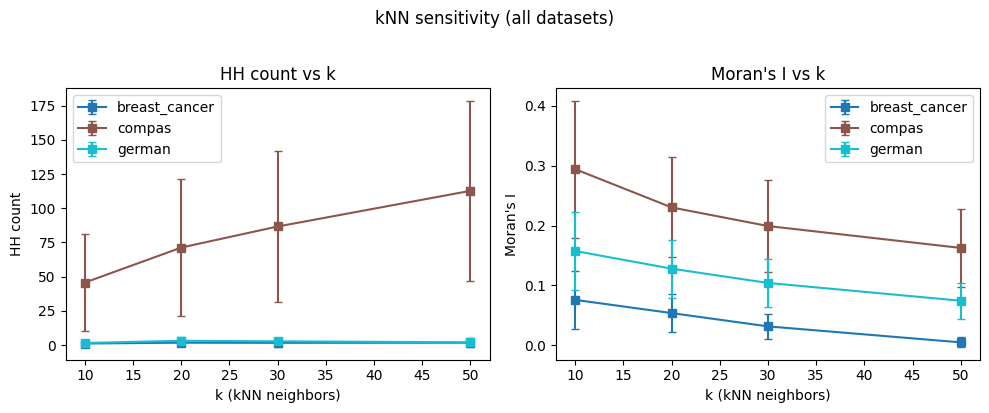

In [3]:
agg_knn = df_knn.groupby(["dataset", "k_nn"]).agg(
    mean_variance_mean=("mean_variance", "mean"), mean_variance_std=("mean_variance", "std"),
    moran_mean=("moran_i", "mean"), moran_std=("moran_i", "std"),
    n_hh_mean=("n_hh", "mean"), n_hh_std=("n_hh", "std"),
).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
colors = plt.cm.tab10(np.linspace(0, 1, df_knn["dataset"].nunique()))
for (ds, grp), c in zip(agg_knn.groupby("dataset"), colors):
    d = grp
    ax1.errorbar(d["k_nn"], d["n_hh_mean"], yerr=d["n_hh_std"], marker="s", capsize=3, label=ds, color=c)
    ax2.errorbar(d["k_nn"], d["moran_mean"], yerr=d["moran_std"], marker="s", capsize=3, label=ds, color=c)
ax1.set_xlabel("k (kNN neighbors)"); ax1.set_ylabel("HH count"); ax1.set_title("HH count vs k"); ax1.legend()
ax2.set_xlabel("k (kNN neighbors)"); ax2.set_ylabel("Moran's I"); ax2.set_title("Moran's I vs k"); ax2.legend()
fig.suptitle("kNN sensitivity (all datasets)", y=1.02)
fig.tight_layout()
plt.show()

## Interpret stability

If spatial statistics change little for k ≥ 20–30, the kNN graph choice is stable.